## 3. Aer Estimator - qiskit_aer

---

In [84]:
from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicSimulator
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer import *
from qiskit_aer import noise

from qiskit.visualization import plot_histogram, plot_distribution
import matplotlib.pyplot as plt

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor':   '#282c34',  
    'axes.facecolor':     '#1e1e1e',    
    'grid.color':         '#444444',

    'figure.figsize': (10, 6),
    'figure.dpi': 150
})    

In [3]:
simulator_basic = BasicSimulator()
simulator_aer = AerSimulator()

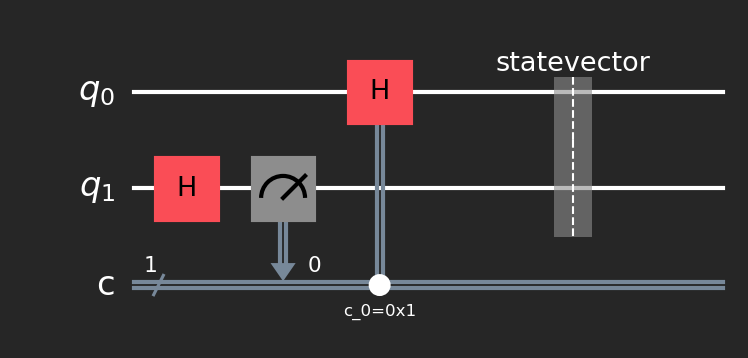

In [4]:
qc = QuantumCircuit(2,1)
qc.h(1)
qc.measure(1,0)
qc.h(0).c_if(0,1)
qc.save_statevector()
qc.draw()

In [5]:
result = simulator_aer.run(transpile(qc, simulator_aer)).result()
print(result.get_counts())

{'0': 503, '1': 521}


In [6]:
for a in range(5):
    result = simulator_aer.run(qc).result()
    ψ = result.get_statevector()
    display(ψ)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

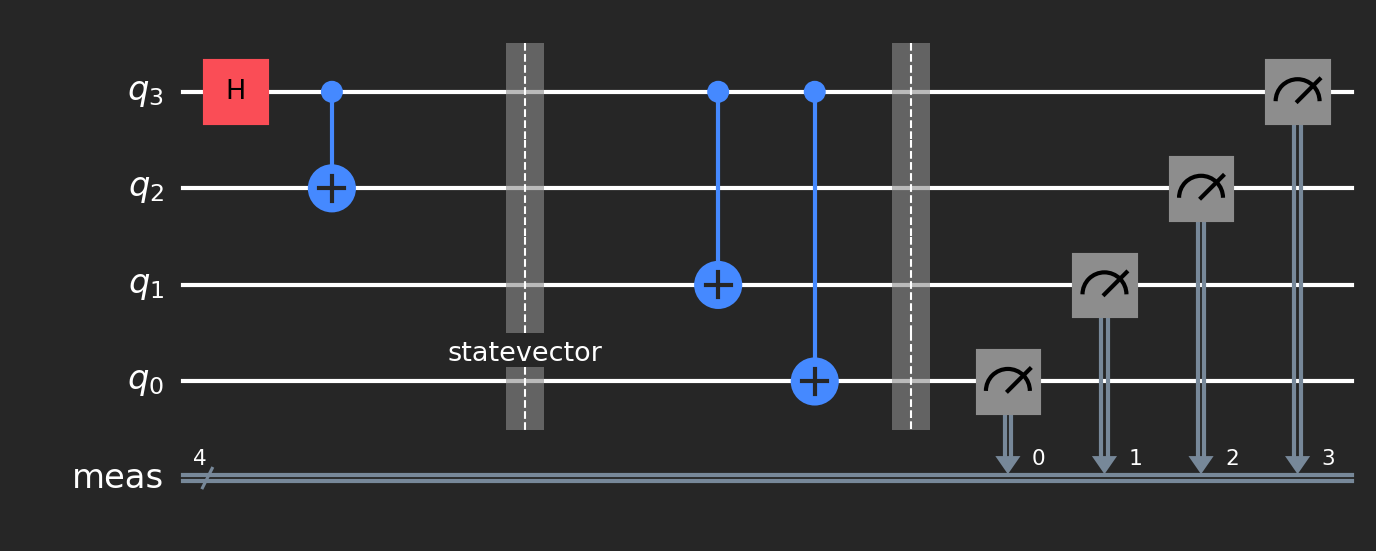

In [7]:
qc = QuantumCircuit(4)
qc.h(3)
qc.cx(3,2)
qc.save_statevector()
qc.cx(3,1)
qc.cx(3,0)
qc.measure_all()
qc.draw(reverse_bits = True)

In [8]:
qc_aer = transpile(qc, backend=simulator_aer)

result = simulator_aer.run(qc_aer).result()
ψ = result.get_statevector()
ψ

<IPython.core.display.Latex object>

## Simulators

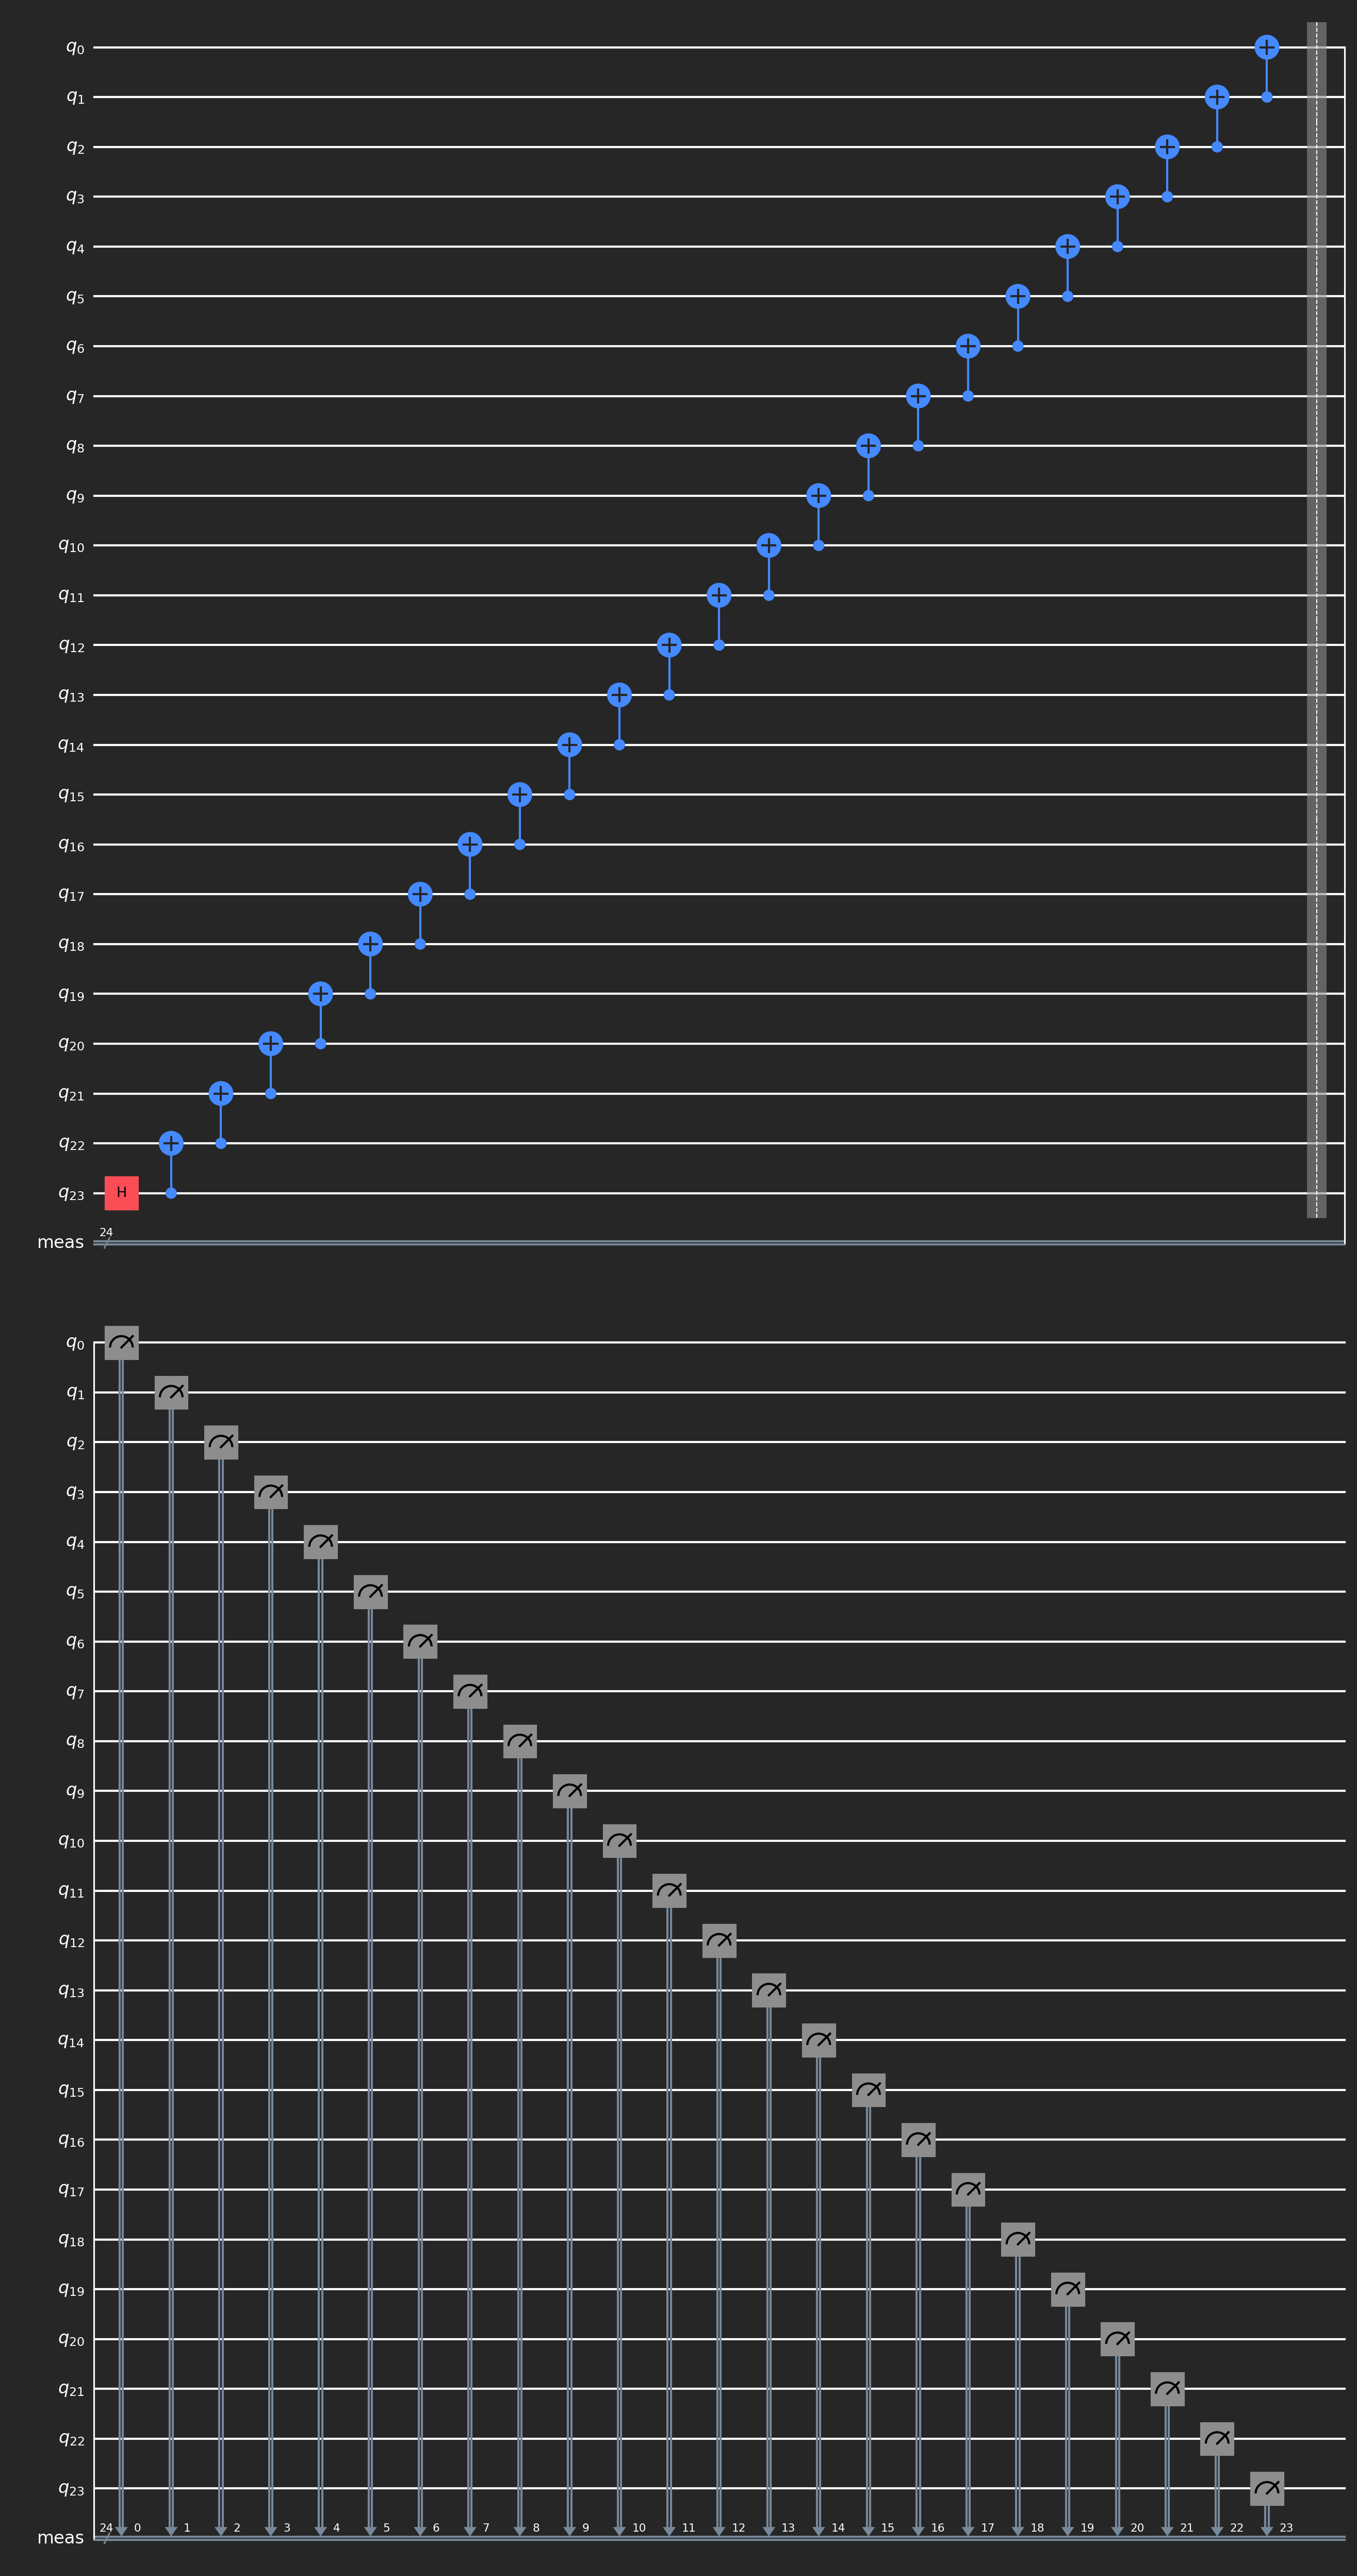

In [9]:
n = 24
qc = QuantumCircuit(n)
qc.h(n-1)
for i in range(n-1,0,-1):
    qc.cx(i,i-1)

qc.measure_all()
qc.draw()

In [10]:
%%time 

result = simulator_basic.run(qc, shots = 1024).result()
counts = result.get_counts()
print(counts)

{'111111111111111111111111': 503, '000000000000000000000000': 521}
CPU times: user 5.51 s, sys: 1.32 s, total: 6.82 s
Wall time: 6.82 s


In [11]:
%%time 

result = simulator_aer.run(qc, shots = 1024, method='statevector').result()
counts = result.get_counts()
print(counts)

{'111111111111111111111111': 522, '000000000000000000000000': 502}
CPU times: user 3.09 s, sys: 615 ms, total: 3.71 s
Wall time: 235 ms


In [12]:
%%time 

result = simulator_aer.run(qc, shots = 1024, method='matrix_product_state').result()
counts = result.get_counts()
print(counts)

{'000000000000000000000000': 510, '111111111111111111111111': 514}
CPU times: user 187 ms, sys: 65.9 ms, total: 253 ms
Wall time: 16.3 ms


## Noise

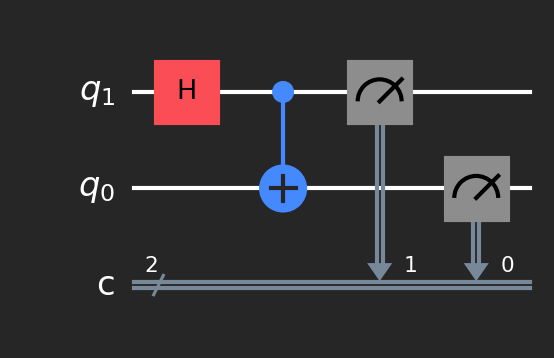

In [13]:
qc = QuantumCircuit(2,2)
qc.h(1)
qc.cx(1,0)
qc.measure([1,0],[1,0])
qc.draw(reverse_bits = True)

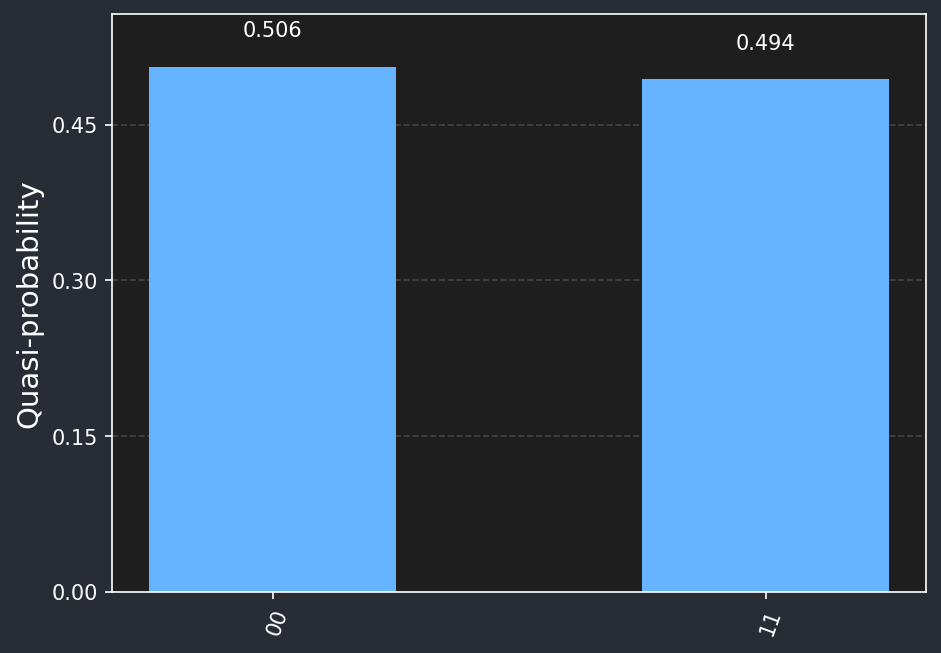

In [14]:
qc_aer = transpile(qc, backend=simulator_aer)
result_ideal = simulator_aer.run(qc_aer, shots = 1024).result()
counts_ideal = result_ideal.get_counts()
plot_distribution(counts_ideal, color = ['#66b3ff'])

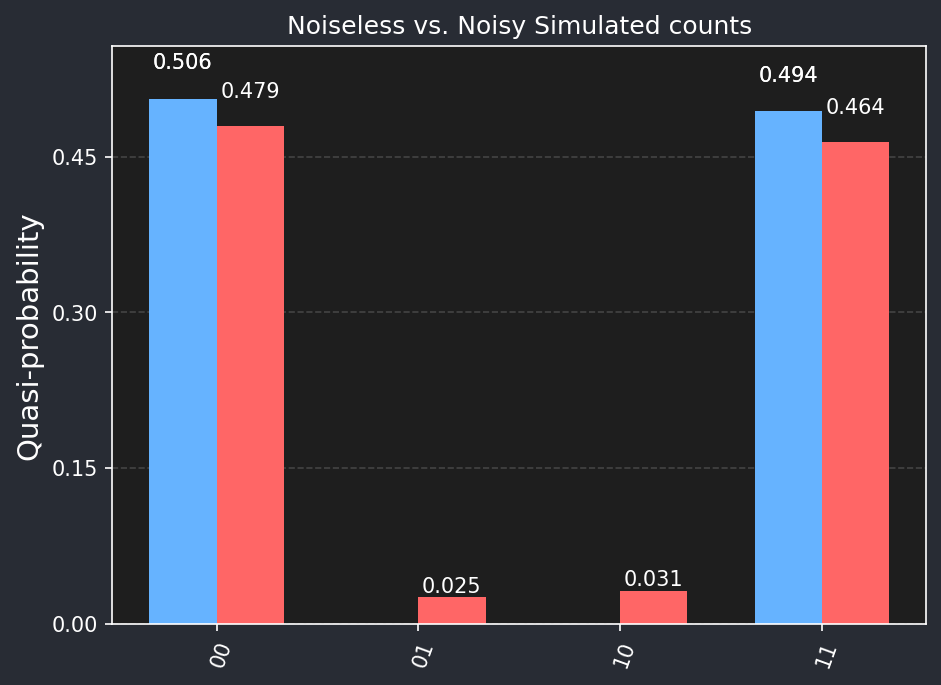

In [15]:
prob = 0.1
error = noise.depolarizing_error(prob, 2)

noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cx'])
basis_gates = noise_model.basis_gates

result_noisy = simulator_aer.run(qc,
                                 shots = 1024,
                                 noise_model=noise_model,
                                 basis_gates=basis_gates).result()

counts_noisy = result_noisy.get_counts()
plot_distribution([counts_ideal, counts_noisy], title='Noiseless vs. Noisy Simulated counts', color = ['#66b3ff', "#ff6666"])


### Imitando QC Reais - ibm_brisbane

In [16]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
real_backend = service.backend("ibm_brisbane")

In [17]:
noisy_simulator = AerSimulator.from_backend(real_backend)
simulator_aer = AerSimulator()

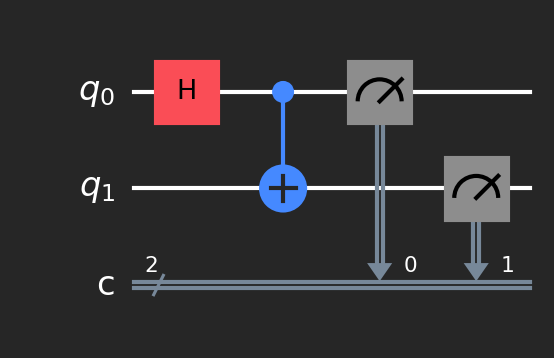

In [18]:
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure([0, 1], [0, 1])
circuit.draw()

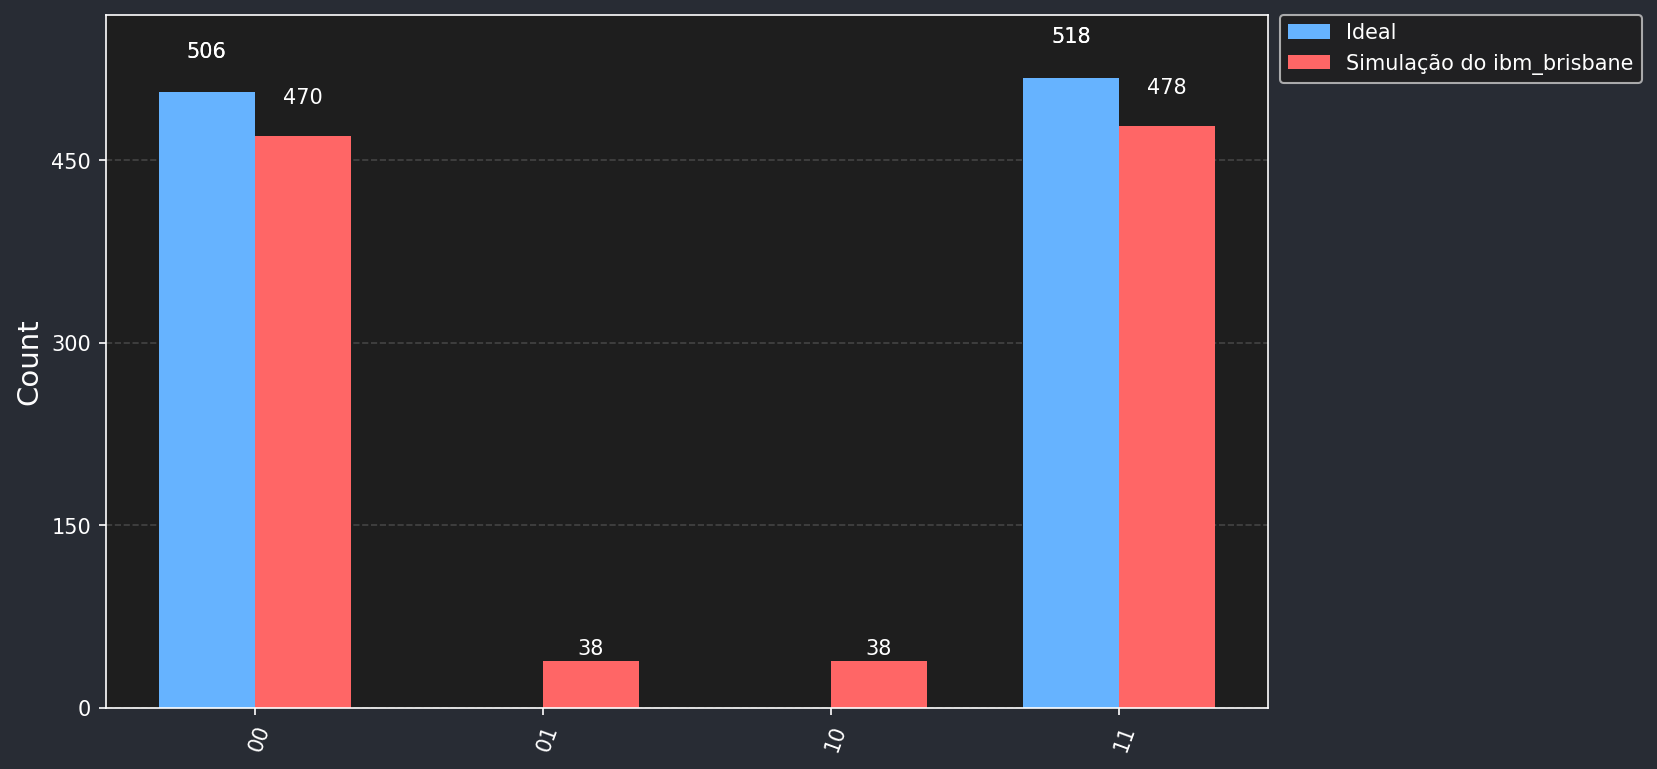

In [19]:
qc_aer = transpile(circuit, backend=simulator_aer)
result_ideal = simulator_aer.run(qc_aer, shots = 1024).result()
counts_ideal = result_ideal.get_counts()

transpiled_noisy = transpile(circuit, noisy_simulator)
result_noisy = noisy_simulator.run(transpiled_noisy, shots=1024).result()
counts_noisy = result_noisy.get_counts()

plot_histogram([counts_ideal, counts_noisy], legend=['Ideal', f'Simulação do {real_backend.name}'], color = ['#66b3ff', "#ff6666"])


---

## Documentação no Qiskit Aer

[AerSimulator](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html)

`class AerSimulator(configuration=None, properties=None, provider=None, target=None, **backend_options)`



---

### Configuration

Utilizado para configuração mais aprofundada, como:

- backend_name: O nome do seu simulador.
- backend_version: A versão.
- n_qubits: O número de qubits.
- basis_gates: A lista de portas nativas que a máquina pode executar.
- coupling_map: O mapa de conectividade física entre os qubits.
- max_shots: O número máximo de shots que o backend suporta por execução.


In [28]:
print(simulator_aer.configuration().to_dict())

{'backend_name': 'aer_simulator', 'backend_version': '0.14.2', 'n_qubits': 29, 'basis_gates': ['ccx', 'ccz', 'cp', 'crx', 'cry', 'crz', 'cswap', 'csx', 'cu', 'cu1', 'cu2', 'cu3', 'cx', 'cy', 'cz', 'diagonal', 'ecr', 'h', 'id', 'initialize', 'mcp', 'mcphase', 'mcr', 'mcrx', 'mcry', 'mcrz', 'mcswap', 'mcsx', 'mcu', 'mcu1', 'mcu2', 'mcu3', 'mcx', 'mcx_gray', 'mcy', 'mcz', 'multiplexer', 'p', 'pauli', 'r', 'roerror', 'rx', 'rxx', 'ry', 'ryy', 'rz', 'rzx', 'rzz', 's', 'sdg', 'swap', 'sx', 'sxdg', 't', 'tdg', 'u', 'u1', 'u2', 'u3', 'unitary', 'x', 'y', 'z', 'break_loop', 'continue_loop', 'delay', 'for_loop', 'if_else', 'kraus', 'qerror_loc', 'quantum_channel', 'reset', 'roerror', 'save_amplitudes', 'save_amplitudes_sq', 'save_clifford', 'save_density_matrix', 'save_expval', 'save_expval_var', 'save_matrix_product_state', 'save_probabilities', 'save_probabilities_dict', 'save_stabilizer', 'save_state', 'save_statevector', 'save_statevector_dict', 'save_superop', 'save_unitary', 'set_density_m

In [29]:
brisbane_config = real_backend.configuration()

print(brisbane_config.to_dict())

{'backend_name': 'ibm_brisbane', 'backend_version': '1.1.167', 'n_qubits': 127, 'basis_gates': ['ecr', 'id', 'rz', 'sx', 'x'], 'gates': [{'name': 'id', 'parameters': [], 'qasm_def': 'gate id q { U(0, 0, 0) q; }', 'coupling_map': [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14], [15], [16], [17], [18], [19], [20], [21], [22], [23], [24], [25], [26], [27], [28], [29], [30], [31], [32], [33], [34], [35], [36], [37], [38], [39], [40], [41], [42], [43], [44], [45], [46], [47], [48], [49], [50], [51], [52], [53], [54], [55], [56], [57], [58], [59], [60], [61], [62], [63], [64], [65], [66], [67], [68], [69], [70], [71], [72], [73], [74], [75], [76], [77], [78], [79], [80], [81], [82], [83], [84], [85], [86], [87], [88], [89], [90], [91], [92], [93], [94], [95], [96], [97], [98], [99], [100], [101], [102], [103], [104], [105], [106], [107], [108], [109], [110], [111], [112], [113], [114], [115], [116], [117], [118], [119], [120], [121], [122], [123], [124], [125]

In [30]:
noisy_simulator = AerSimulator.from_backend(real_backend)
noisy_simulator_from_config = AerSimulator(configuration = brisbane_config)

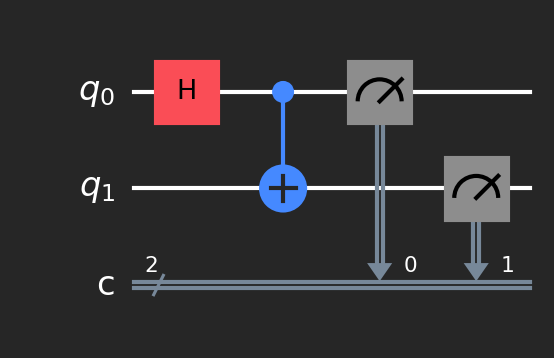

In [31]:
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure([0, 1], [0, 1])
circuit.draw()

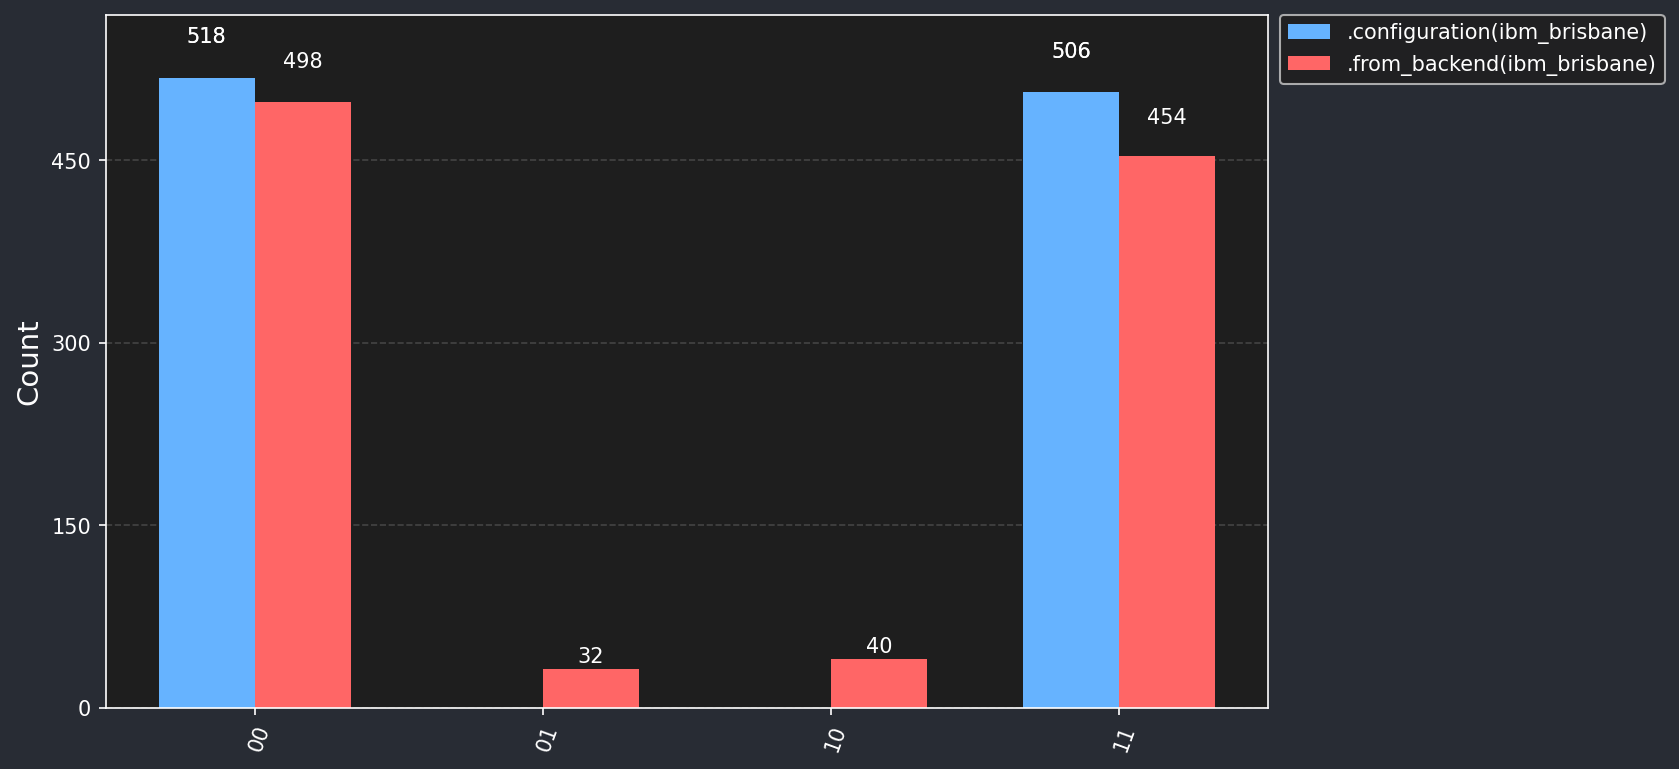

In [33]:
transpiled_config = transpile(circuit, backend=noisy_simulator_from_config)
result_config = noisy_simulator_from_config.run(transpiled_config, shots = 1024).result()
counts_config = result_config.get_counts()

transpiled_noisy = transpile(circuit, noisy_simulator)
result_noisy = noisy_simulator.run(transpiled_noisy, shots=1024).result()
counts_noisy = result_noisy.get_counts()

plot_histogram([counts_config, counts_noisy], legend=[f'.configuration({real_backend.name})', f'.from_backend({real_backend.name})'], color = ['#66b3ff', "#ff6666"])


In [35]:
print(noisy_simulator_from_config.configuration().to_dict())
print(noisy_simulator.configuration().to_dict())

{'backend_name': 'ibm_brisbane', 'backend_version': '1.1.167', 'n_qubits': 127, 'basis_gates': ['ccx', 'ccz', 'cp', 'crx', 'cry', 'crz', 'cswap', 'csx', 'cu', 'cu1', 'cu2', 'cu3', 'cx', 'cy', 'cz', 'diagonal', 'ecr', 'h', 'id', 'initialize', 'mcp', 'mcphase', 'mcr', 'mcrx', 'mcry', 'mcrz', 'mcswap', 'mcsx', 'mcu', 'mcu1', 'mcu2', 'mcu3', 'mcx', 'mcx_gray', 'mcy', 'mcz', 'multiplexer', 'p', 'pauli', 'r', 'roerror', 'rx', 'rxx', 'ry', 'ryy', 'rz', 'rzx', 'rzz', 's', 'sdg', 'swap', 'sx', 'sxdg', 't', 'tdg', 'u', 'u1', 'u2', 'u3', 'unitary', 'x', 'y', 'z', 'break_loop', 'continue_loop', 'delay', 'for_loop', 'if_else', 'kraus', 'qerror_loc', 'quantum_channel', 'reset', 'roerror', 'save_amplitudes', 'save_amplitudes_sq', 'save_clifford', 'save_density_matrix', 'save_expval', 'save_expval_var', 'save_matrix_product_state', 'save_probabilities', 'save_probabilities_dict', 'save_stabilizer', 'save_state', 'save_statevector', 'save_statevector_dict', 'save_superop', 'save_unitary', 'set_density_

Repare aqui que ao rodar a comparação entre noisy_simulator_from_config (.configuration())e noisy_simulator (.from_backend()), temos resultados bastante distintos, o noisy_simulator_from_config não possui um modelo de noise, apesar de possuir a mesma configuração do noisy_simulator. 

---

### Proprieties

Contem as informações presentes sobre ruido do backend escolhido

- backend_name
- backend_version
- last_update_date
- qubits : Readout Errors, Tempo de Decoerência e Relaxamento 
- gates : Error, Noise Model e Duração do Gate
- general

In [37]:
print(simulator_aer.properties())

None


In [74]:
brisbane_proprieties = noisy_simulator.properties()
brisbane_proprieties_dict = brisbane_proprieties.to_dict()

print(brisbane_proprieties_dict)

print(f"\nLista de propriedades : \n")


print(*list(f"•{a}" for a in brisbane_proprieties_dict.keys()), sep='\n')

{'backend_name': '', 'backend_version': '', 'last_update_date': None, 'qubits': [[{'date': datetime.datetime(2025, 7, 31, 19, 55, 29, 511681, tzinfo=datetime.timezone.utc), 'name': 'readout_error', 'unit': '', 'value': 0.0419921875}, {'date': datetime.datetime(2025, 7, 31, 19, 55, 29, 511681, tzinfo=datetime.timezone.utc), 'name': 'readout_length', 'unit': 's', 'value': 1.3e-06}], [{'date': datetime.datetime(2025, 7, 31, 19, 55, 29, 511682, tzinfo=datetime.timezone.utc), 'name': 'readout_error', 'unit': '', 'value': 0.025146484375}, {'date': datetime.datetime(2025, 7, 31, 19, 55, 29, 511682, tzinfo=datetime.timezone.utc), 'name': 'readout_length', 'unit': 's', 'value': 1.3e-06}], [{'date': datetime.datetime(2025, 7, 31, 19, 55, 29, 511683, tzinfo=datetime.timezone.utc), 'name': 'readout_error', 'unit': '', 'value': 0.00732421875}, {'date': datetime.datetime(2025, 7, 31, 19, 55, 29, 511683, tzinfo=datetime.timezone.utc), 'name': 'readout_length', 'unit': 's', 'value': 1.3e-06}], [{'date

In [75]:
noisy_simulator = AerSimulator.from_backend(real_backend)
noisy_simulator_proprieties_config = AerSimulator(configuration = brisbane_config, properties = brisbane_proprieties)

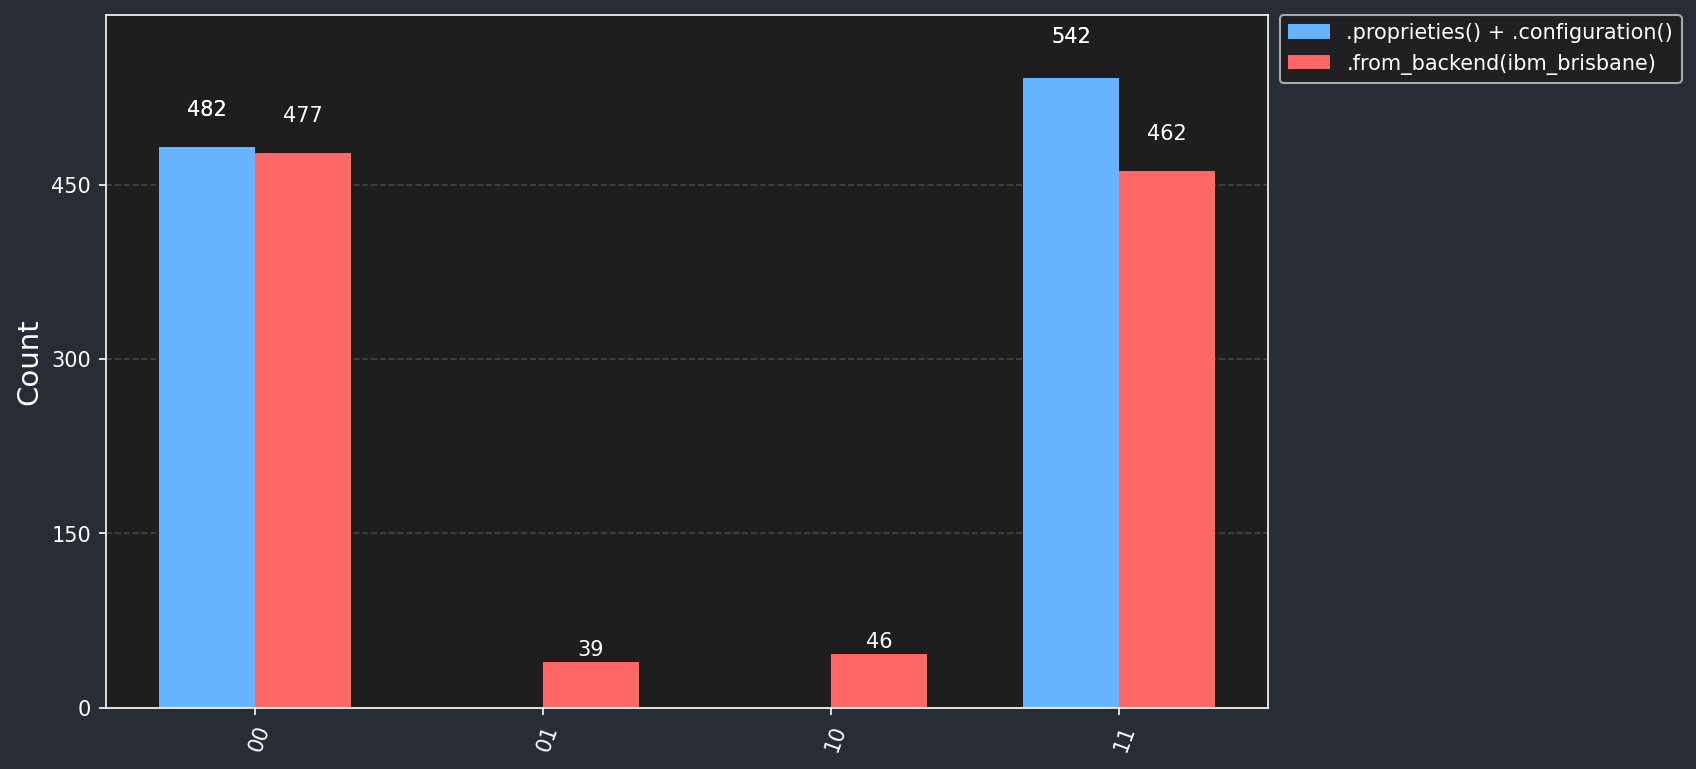

In [76]:
transpiled_prop = transpile(circuit, backend=noisy_simulator_proprieties_config)
result_prop = noisy_simulator_proprieties_config.run(transpiled_prop, shots = 1024).result()
counts_prop = result_prop.get_counts()

transpiled_noisy = transpile(circuit, noisy_simulator)
result_noisy = noisy_simulator.run(transpiled_noisy, shots=1024).result()
counts_noisy = result_noisy.get_counts()

plot_histogram([counts_prop, counts_noisy], legend=[f'.proprieties() + .configuration()', f'.from_backend({real_backend.name})'], color = ['#66b3ff', "#ff6666"])

Novamente podemos perceber que o gráfico utilizando o .proprieties() + .configuration() é ativamente diferente do .from_backend(). Isso se deve pelo motivo de não termos fornecido um NoiseModel em Backend_Options para o AerSimulator, fornecer o .proprieties() + .configuration() é apenas uma medida de DOCUMENTAÇÃO, e não é responsável pelo modelo de erros utilizado.

---

### Provider

Não tem utilidade, não precisamos de um provider para chamar o backend do AerSimulator, já que ele roda localmente (DeprecationWarning).

In [129]:
AerSimulator().available_devices()

('CPU',)

In [86]:
AerProvider().backends()

/tmp/ipykernel_22106/2100249447.py:1: DeprecationWarning: The class ``qiskit.providers.provider.Provider`` is deprecated as of qiskit 1.1. It will be removed no earlier than 3 months after the release date. The abstract Provider and ProviderV1 classes are deprecated and will be removed in 2.0. You can just remove it as the parent class and a `get_backend` method that returns the backends from `self.backend`.
  AerProvider().backends()


[AerSimulator('aer_simulator'),
 AerSimulator('aer_simulator_statevector'),
 AerSimulator('aer_simulator_density_matrix'),
 AerSimulator('aer_simulator_stabilizer'),
 AerSimulator('aer_simulator_matrix_product_state'),
 AerSimulator('aer_simulator_extended_stabilizer'),
 AerSimulator('aer_simulator_unitary'),
 AerSimulator('aer_simulator_superop'),
 QasmSimulator('qasm_simulator'),
 StatevectorSimulator('statevector_simulator'),
 UnitarySimulator('unitary_simulator')]

---

### Target


O target é uma maneira de providenciar várias informações do Backend, assim como um conjunto do .configuration() e .properties()

In [98]:
print(*list(f"{a}" for a in AerSimulator().target), sep = ", \t")

cry, 	y, 	cswap, 	mcu1, 	while_loop, 	u2, 	measure, 	qerror_loc, 	cu3, 	mcphase, 	roerror, 	csx, 	save_state, 	save_statevector_dict, 	p, 	h, 	mcry, 	pauli, 	sxdg, 	unitary, 	reset, 	rx, 	diagonal, 	initialize, 	multiplexer, 	save_unitary, 	cp, 	ccx, 	crz, 	delay, 	mcswap, 	mcsx, 	cy, 	mcy, 	sdg, 	save_clifford, 	x, 	set_unitary, 	mcu3, 	save_expval_var, 	cx, 	rzz, 	for_loop, 	kraus, 	mcu2, 	if_else, 	superop, 	id, 	save_statevector, 	save_matrix_product_state, 	ccz, 	mcp, 	s, 	ryy, 	swap, 	z, 	mcr, 	save_superop, 	cu, 	save_probabilities_dict, 	save_expval, 	set_density_matrix, 	r, 	save_probabilities, 	rxx, 	set_superop, 	set_stabilizer, 	sx, 	cu2, 	rzx, 	cu1, 	t, 	ry, 	cz, 	continue_loop, 	mcrz, 	u1, 	save_density_matrix, 	tdg, 	u, 	save_stabilizer, 	break_loop, 	rz, 	save_amplitudes_sq, 	u3, 	mcx, 	mcu, 	crx, 	set_matrix_product_state, 	set_statevector, 	quantum_channel, 	mcz, 	ecr, 	mcx_gray, 	mcrx, 	switch_case, 	save_amplitudes


In [100]:
print(AerSimulator().target)

Target
Number of qubits: 29
Instructions:
	cry
	y
	cswap
	mcu1
	while_loop
	u2
	measure
		(0,)
		(1,)
		(2,)
		(3,)
		(4,)
		(5,)
		(6,)
		(7,)
		(8,)
		(9,)
		(10,)
		(11,)
		(12,)
		(13,)
		(14,)
		(15,)
		(16,)
		(17,)
		(18,)
		(19,)
		(20,)
		(21,)
		(22,)
		(23,)
		(24,)
		(25,)
		(26,)
		(27,)
		(28,)
	qerror_loc
	cu3
	mcphase
	roerror
	csx
	save_state
	save_statevector_dict
	p
	h
	mcry
	pauli
	sxdg
	unitary
	reset
	rx
	diagonal
	initialize
	multiplexer
	save_unitary
	cp
	ccx
	crz
	delay
		(0,)
		(1,)
		(2,)
		(3,)
		(4,)
		(5,)
		(6,)
		(7,)
		(8,)
		(9,)
		(10,)
		(11,)
		(12,)
		(13,)
		(14,)
		(15,)
		(16,)
		(17,)
		(18,)
		(19,)
		(20,)
		(21,)
		(22,)
		(23,)
		(24,)
		(25,)
		(26,)
		(27,)
		(28,)
	mcswap
	mcsx
	cy
	mcy
	sdg
	save_clifford
	x
	set_unitary
	mcu3
	save_expval_var
	cx
	rzz
	for_loop
	kraus
	mcu2
	if_else
	superop
	id
	save_statevector
	save_matrix_product_state
	ccz
	mcp
	s
	ryy
	swap
	z
	mcr
	save_superop
	cu
	save_probabilities_dict
	save_expval
	set_dens

In [121]:
import inspect

brisbane_target = real_backend.target

print(*[f"• {a}" for a in dir(brisbane_target) if not a.startswith('_')], sep = "\n")

• acquire_alignment
• add_instruction
• build_coupling_map
• concurrent_measurements
• description
• dt
• durations
• from_configuration
• get
• get_calibration
• get_non_global_operation_names
• granularity
• has_calibration
• instruction_properties
• instruction_schedule_map
• instruction_supported
• instructions
• items
• keys
• min_length
• num_qubits
• operation_from_name
• operation_names
• operation_names_for_qargs
• operations
• operations_for_qargs
• physical_qubits
• pulse_alignment
• qargs
• qargs_for_operation_name
• qubit_properties
• timing_constraints
• update_from_instruction_schedule_map
• update_instruction_properties
• values


In [126]:
print(f"operation_names : {brisbane_target.operation_names}")
print(f"granularity : {brisbane_target.granularity}")
print(f"dt : {brisbane_target.dt}")

operation_names : dict_keys(['id', 'rz', 'sx', 'x', 'ecr', 'reset', 'measure', 'delay'])
granularity : 8
dt : 5e-10


---

### Backend Options